In [ ]:
#%pip install torch torchvision torchaudio
#%pip install mediapipe opencv-python pillow
#%pip install pandas matplotlib seaborn tqdm scikit-learn
#%pip install albumentations  # для будущей аугментации

Предобработка датасета для классификации эмоций

Общее описание

Скрипт подготавливает данные для обучения нейросети распознаванию эмоций на лицах. Входные данные — папки с фотографиями (train и test), 
выходные — очищенные и нормализованные изображения лиц размером 224×224 пикселя.

Что происходит в процессе

- Удаление дубликатов — все одинаковые изображения находятся по хешу и удаляются.

- Детекция лиц — с помощью каскадов Хаара (OpenCV) находится самое крупное лицо на каждом фото. 
  Изображения без лиц отбрасываются.

- Обрезка и нормализация — лицо вырезается, к нему применяются автоконтраст и коррекция яркости.

- Ресайз — все обрезанные лица приводятся к единому размеру 224×224.

- Сохранение — обработанные изображения раскладываются по папкам:

processed_data/train_cropped_faces/ — тренировочные данные по классам

processed_data/test_cropped_faces/ — тестовые данные

Генерация отчётов — в processed_data/ сохраняются CSV-файлы с метаданными и текстовые отчёты со статистикой.

Используемые инструменты

- OpenCV — детектор лиц (каскады Хаара)

- PIL — работа с изображениями

- Pandas — метаданные

- Matplotlib + Seaborn — визуализация

Результат

На выходе получается чистый датасет без дубликатов, с центрированными лицами одного размера — готовый для подачи в классификатор.

PyTorch версия: 2.2.2
Torchvision версия: 0.17.2
Используемое устройство: cpu
Используется CPU (ожидайте более медленной обработки)
Удаляем старые обработанные данные: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/processed_data

НАЧАЛО ПОЛНОЙ ПРЕДОБРАБОТКИ ДАННЫХ
ПОЛНАЯ ПРЕДОБРАБОТКА ДАННЫХ С ДЕТЕКЦИЕЙ ЛИЦ
Тренировочные данные: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/train
Тестовые данные: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/test_kaggle

[Шаг 1/4] ВЫПОЛНЕНИЕ ПОЛНОГО EDA АНАЛИЗА С УДАЛЕНИЕМ ДУБЛИКАТОВ
----------------------------------------
ПОЛНЫЙ EDA АНАЛИЗ С УДАЛЕНИЕМ ДУБЛИКАТОВ

[1/3] Поиск и удаление дубликатов...

ПОИСК И УДАЛЕНИЕ ДУБЛИКАТОВ (ВСЕ ИЗОБРАЖЕНИЯ)
Анализируем 49310 изображений на дубликаты...


Вычисление хешей: 100%|███████████████████| 49310/49310 [08:58<00:00, 91.65it/s]


Дубликаты не найдены

[2/3] Анализ статистики...

АНАЛИЗ СТАТИСТИКИ ПОСЛЕ УДАЛЕНИЯ ДУБЛИКАТОВ


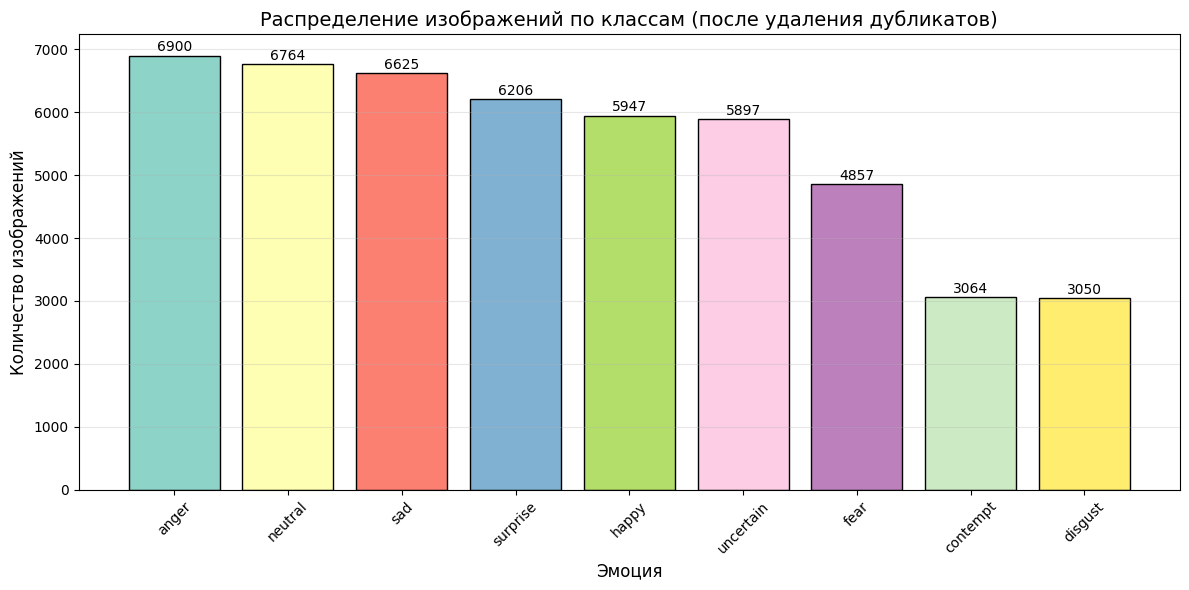

Общее количество изображений: 49310
Удалено дубликатов: 0

Статистика по классам:
    class  count  percentage
    anger   6900       13.99
  neutral   6764       13.72
      sad   6625       13.44
 surprise   6206       12.59
    happy   5947       12.06
uncertain   5897       11.96
     fear   4857        9.85
 contempt   3064        6.21
  disgust   3050        6.19

Анализ дисбаланса:
  Максимальный класс: anger (6900 изображений)
  Минимальный класс: disgust (3050 изображений)
  Коэффициент дисбаланса: 2.26x

[3/3] Создание отчета...
Отчет сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/processed_data/eda_complete_report.txt

EDA АНАЛИЗ ЗАВЕРШЕН

[Шаг 2/4] ИНИЦИАЛИЗАЦИЯ ПРЕДОБРАБОТЧИКА С ДЕТЕКЦИЕЙ ЛИЦ
----------------------------------------
Скачиваем файл с каскадами Хаара...
Файл скачан
OpenCV детектор загружен

[Шаг 3/4] ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ДЕТЕКЦИИ ЛИЦ
----------------------------------------

ВИЗУАЛИЗА

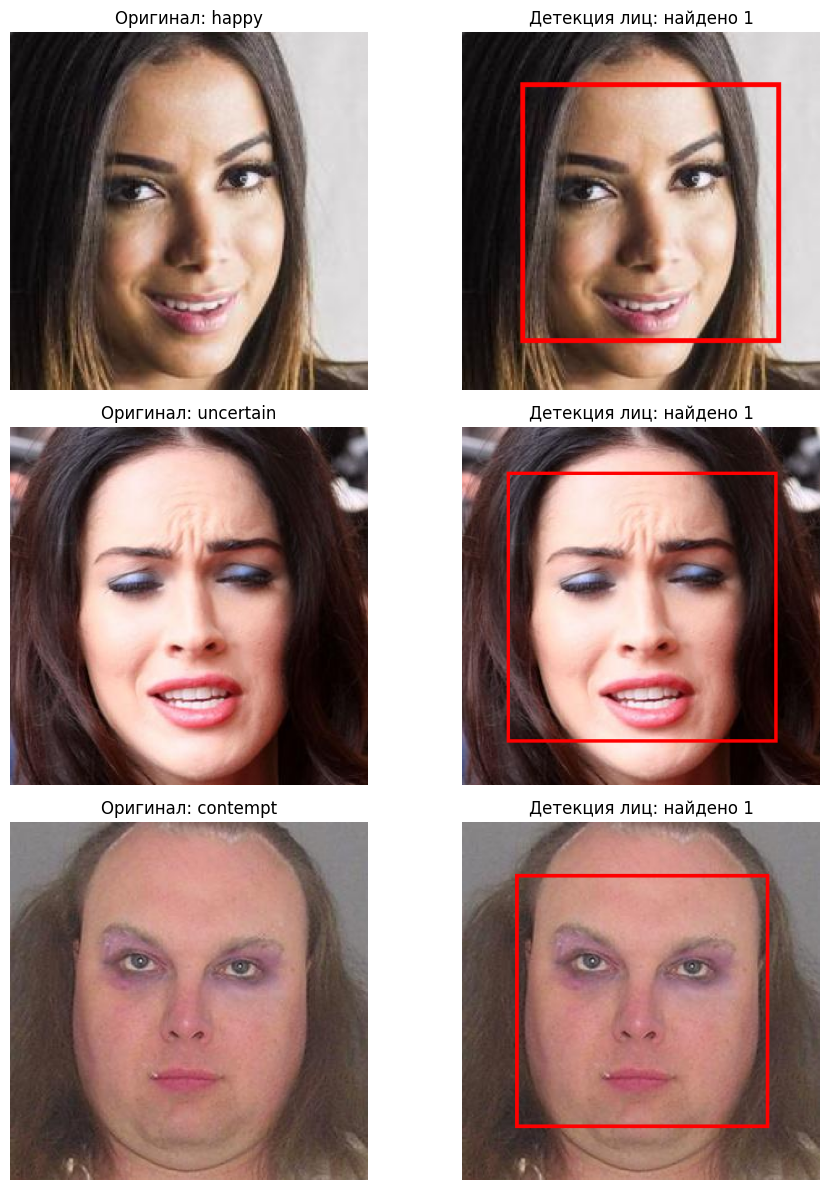


[Шаг 4/4] ОБРАБОТКА ВСЕХ ДАННЫХ
----------------------------------------

4.1 Обработка тренировочных данных...

ОБРАБОТКА ТРЕНИРОВОЧНЫХ ИЗОБРАЖЕНИЙ С ДЕТЕКЦИЕЙ ЛИЦ
Всего изображений для обработки: 49310

Класс happy: 5947 изображений


Обработка happy: 100%|██████████████████████| 5947/5947 [08:46<00:00, 11.29it/s]


  Успешно: 5744, Неудачно: 203

Класс uncertain: 5897 изображений


Обработка uncertain: 100%|██████████████████| 5897/5897 [07:41<00:00, 12.78it/s]


  Успешно: 5554, Неудачно: 343

Класс contempt: 3064 изображений


...

  Успешно: 6574, Неудачно: 326

Класс disgust: 3050 изображений


Обработка disgust: 100%|████████████████████| 3050/3050 [03:29<00:00, 14.58it/s]


  Успешно: 2907, Неудачно: 143

СТАТИСТИКА ОБРАБОТКИ ТРЕНИРОВОЧНЫХ ДАННЫХ
Всего обработано: 49310
Успешно (лица найдены): 46770
Пропущено (лица не найдены): 2540
Ошибки: 0
Успешность обработки: 94.8%

Распределение по классам (успешные):
  anger: 6574
  neutral: 6456
  sad: 6173
  surprise: 5835
  happy: 5744
  uncertain: 5554
  fear: 4557
  contempt: 2970
  disgust: 2907

4.2 Обработка тестовых данных...

ОБРАБОТКА ТЕСТОВЫХ ИЗОБРАЖЕНИЙ
Найдено тестовых изображений: 5000


Обработка тестовых данных: 100%|████████████| 5000/5000 [06:55<00:00, 12.02it/s]



СТАТИСТИКА ОБРАБОТКИ ТЕСТОВЫХ ДАННЫХ
Всего обработано: 5000
Успешно: 5000
Ошибки: 0
Успешность обработки: 100.0%

СОЗДАНИЕ ИТОГОВОГО ОТЧЕТА

Финальный отчет сохранен: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/processed_data/final_summary_complete.txt

ПРЕДОБРАБОТКА ДАННЫХ УСПЕШНО ЗАВЕРШЕНА!

РЕЗУЛЬТАТЫ ОБРАБОТКИ:
  Тренировочные данные: 46770/49310 успешно (94.8%)
  Лиц найдено: 46770
  Лиц не найдено: 2540

Все данные сохранены в: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/processed_data
Обработанные тренировочные изображения: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/processed_data/train_cropped_faces
Обработанные тестовые изображения: /Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22/processed_data/test_cropped_faces

Д

In [5]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageOps, ImageEnhance, ImageDraw
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import hashlib
import gc
# PyTorch импорты
import torch
#import torchvision
#from torchvision.models.detection import fasterrcnn_resnet50_fpn
#from torchvision.transforms import functional as F
import cv2
import urllib.request

# Настройки для воспроизводимости
def set_seed(seed=42):
    """Установка seed для воспроизводимости"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Конфигурация
class Config:
    # Пути
    BASE_DIR = Path("/Users/ostroverkhovpavel/Documents/SkillBoxHomeworks/Data Scientist. ML. Средний уровень (нейронные сети)/22")
    RAW_TRAIN_DIR = BASE_DIR / "train"
    RAW_TEST_DIR = BASE_DIR / "test_kaggle"
    
    # Директории для обработанных данных
    PROCESSED_DIR = BASE_DIR / "processed_data"
    PROCESSED_TRAIN_DIR = PROCESSED_DIR / "train_cropped_faces"
    PROCESSED_VAL_DIR = PROCESSED_DIR / "val_cropped_faces" 
    PROCESSED_TEST_DIR = PROCESSED_DIR / "test_cropped_faces"
    
    # Файлы метаданных
    TRAIN_CSV = BASE_DIR / "train.csv"
    TEST_CSV = BASE_DIR / "sample_submission.csv"
    
    # Настройки обработки
    TARGET_SIZE = (224, 224)  # Размер для ресайза
    MIN_FACE_SIZE = 50  # Минимальный размер лица
    FACE_CONFIDENCE_THRESHOLD = 0.7  # Порог уверенности для детекции лица
    
    # Настройки устройства
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # EDA настройки
    SAMPLE_PER_CLASS = 30

config = Config()

# Создание директорий
for dir_path in [config.PROCESSED_DIR, config.PROCESSED_TRAIN_DIR, 
                 config.PROCESSED_VAL_DIR, config.PROCESSED_TEST_DIR]:
    dir_path.mkdir(exist_ok=True, parents=True)

print(f"PyTorch версия: {torch.__version__}")
print(f"Torchvision версия: {torchvision.__version__}")
print(f"Используемое устройство: {config.DEVICE}")

if config.DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU память: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print(f"Используется CPU (ожидайте более медленной обработки)")

# ============================================================================
# Класс Haar Cascade - детекция лиц с использованием OpenCV
# ============================================================================

import urllib.request
import os

class FaceDetectorOpenCV:
   
    
    def __init__(self):
        # Скачиваем файл каскадов, если его нет
        cascade_file = "haarcascade_frontalface_default.xml"
        
        if not os.path.exists(cascade_file):
            print("Скачиваем файл с каскадами Хаара...")
            url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
            urllib.request.urlretrieve(url, cascade_file)
            print("Файл скачан")
        
        self.face_cascade = cv2.CascadeClassifier(cascade_file)
        print("OpenCV детектор загружен")
    
    def detect_faces(self, image_array, confidence_threshold=0.7):
        """Детекция лиц на изображении"""
        gray = cv2.cvtColor(image_array, cv2.COLOR_RGB2GRAY)
        faces = self.face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(50, 50)
        )
        # Приводим к тому же формату, что и PyTorch версия
        return [(x, y, x+w, y+h) for (x, y, w, h) in faces]
    
    def crop_largest_face(self, image_array, confidence_threshold=0.7):
        """Обрезка наибольшего лица"""
        faces = self.detect_faces(image_array)
        
        if len(faces) == 0:
            return None, None
        
        # Находим лицо с наибольшей площадью
        largest_face = max(faces, key=lambda f: (f[2] - f[0]) * (f[3] - f[1]))
        x1, y1, x2, y2 = largest_face
        
        # Убеждаемся, что координаты в пределах изображения
        h, w = image_array.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        
        # Проверяем минимальный размер
        if (x2 - x1) < config.MIN_FACE_SIZE or (y2 - y1) < config.MIN_FACE_SIZE:
            return None, None
        
        # Обрезаем изображение
        cropped_face = image_array[y1:y2, x1:x2]
        
        return cropped_face, (x1, y1, x2, y2)
        
# ============================================================================
# класс EDAAnalyzer с обработкой дубликатов
# ============================================================================

class ImprovedEDAnalyzer:
    """EDA анализатор с обработкой дубликатов"""
    
    def __init__(self, train_dir, test_dir):
        self.train_dir = Path(train_dir)
        self.test_dir = Path(test_dir)
        self.duplicates_removed = 0
    
    def calculate_image_hash(self, image_path):
        """Вычисление хеша изображения для поиска дубликатов"""
        try:
            with Image.open(image_path) as img:
                # Конвертируем в RGB и ресайзим для ускорения
                img_resized = img.convert('RGB').resize((100, 100), Image.Resampling.LANCZOS)
                img_array = np.array(img_resized)
                
                # Вычисляем хеш
                return hashlib.md5(img_array.tobytes()).hexdigest()
        except Exception as e:
            print(f"Ошибка при вычислении хеша {image_path}: {e}")
            return None
    
    def find_and_remove_duplicates(self):
        """Поиск и удаление дубликатов ВО ВСЕМ датасете"""
        print("\n" + "=" * 60)
        print("ПОИСК И УДАЛЕНИЕ ДУБЛИКАТОВ (ВСЕ ИЗОБРАЖЕНИЯ)")
        print("=" * 60)
        
        # Собираем ВСЕ изображения
        all_images = []
        for class_name in os.listdir(self.train_dir):
            class_path = self.train_dir / class_name
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = class_path / img_file
                        all_images.append((class_name, img_file, str(img_path)))
        
        print(f"Анализируем {len(all_images)} изображений на дубликаты...")
        
        # Словарь для хранения хешей
        hash_dict = {}
        duplicates_to_remove = []
        
        # Вычисляем хеши
        for class_name, img_file, img_path in tqdm(all_images, desc="Вычисление хешей"):
            img_hash = self.calculate_image_hash(img_path)
            if img_hash:
                if img_hash in hash_dict:
                    # Найден дубликат
                    original_class, original_file, original_path = hash_dict[img_hash]
                    duplicates_to_remove.append({
                        'original_class': original_class,
                        'original_file': original_file,
                        'original_path': original_path,
                        'duplicate_class': class_name,
                        'duplicate_file': img_file,
                        'duplicate_path': img_path
                    })
                else:
                    hash_dict[img_hash] = (class_name, img_file, img_path)
        
        # Удаляем дубликаты
        self._remove_duplicate_files(duplicates_to_remove)
        
        return duplicates_to_remove
    
    def _remove_duplicate_files(self, duplicates):
        """Физическое удаление файлов-дубликатов"""
        if not duplicates:
            print("Дубликаты не найдены")
            return
        
        print(f"\nНайдено {len(duplicates)} дубликатов. Удаление...")
        
        for dup in tqdm(duplicates, desc="Удаление дубликатов"):
            dup_path = Path(dup['duplicate_path'])
            if dup_path.exists():
                try:
                    dup_path.unlink()
                    self.duplicates_removed += 1
                except Exception as e:
                    print(f"Ошибка при удалении {dup_path}: {e}")
        
        print(f"Удалено {self.duplicates_removed} файлов-дубликатов")
        
        # Сохраняем информацию о дубликатах
        duplicates_df = pd.DataFrame(duplicates)
        duplicates_path = config.PROCESSED_DIR / 'duplicates_removed.csv'
        duplicates_df.to_csv(duplicates_path, index=False)
        print(f"Информация о дубликатах сохранена: {duplicates_path}")
    
    def analyze_basic_stats(self):
        """Базовый анализ статистики после удаления дубликатов"""
        print("\n" + "=" * 60)
        print("АНАЛИЗ СТАТИСТИКИ ПОСЛЕ УДАЛЕНИЯ ДУБЛИКАТОВ")
        print("=" * 60)
        
        train_classes = [d for d in os.listdir(self.train_dir) 
                        if os.path.isdir(self.train_dir / d)]
        
        class_stats = {}
        total_images = 0
        
        for class_name in train_classes:
            class_path = self.train_dir / class_name
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(images)
            class_stats[class_name] = count
            total_images += count
        
        # Создаем DataFrame для статистики
        stats_df = pd.DataFrame({
            'class': list(class_stats.keys()),
            'count': list(class_stats.values())
        })
        stats_df['percentage'] = (stats_df['count'] / total_images * 100).round(2)
        stats_df = stats_df.sort_values('count', ascending=False)
        
        # Визуализация
        plt.figure(figsize=(12, 6))
        colors = plt.cm.Set3(np.linspace(0, 1, len(stats_df)))
        bars = plt.bar(stats_df['class'], stats_df['count'], color=colors, edgecolor='black')
        
        plt.title('Распределение изображений по классам (после удаления дубликатов)', fontsize=14)
        plt.xlabel('Эмоция', fontsize=12)
        plt.ylabel('Количество изображений', fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        
        # Добавление значений
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 20,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Общее количество изображений: {total_images}")
        print(f"Удалено дубликатов: {self.duplicates_removed}")
        print("\nСтатистика по классам:")
        print(stats_df.to_string(index=False))
        
        # Анализ дисбаланса
        max_count = stats_df['count'].max()
        min_count = stats_df['count'].min()
        imbalance_ratio = max_count / min_count
        
        print(f"\nАнализ дисбаланса:")
        print(f"  Максимальный класс: {stats_df.iloc[0]['class']} ({max_count} изображений)")
        print(f"  Минимальный класс: {stats_df.iloc[-1]['class']} ({min_count} изображений)")
        print(f"  Коэффициент дисбаланса: {imbalance_ratio:.2f}x")
        
        return stats_df
    
    def run_complete_eda(self):
        """Запуск полного EDA анализа с удалением дубликатов"""
        print("=" * 60)
        print("ПОЛНЫЙ EDA АНАЛИЗ С УДАЛЕНИЕМ ДУБЛИКАТОВ")
        print("=" * 60)
        
        # 1. Удаление дубликатов
        print("\n[1/3] Поиск и удаление дубликатов...")
        duplicates = self.find_and_remove_duplicates()
        
        # 2. Анализ статистики после удаления
        print("\n[2/3] Анализ статистики...")
        stats_df = self.analyze_basic_stats()
        
        # 3. Сохранение отчета
        print("\n[3/3] Создание отчета...")
        self._create_eda_report(stats_df, len(duplicates))
        
        print("\n" + "=" * 60)
        print("EDA АНАЛИЗ ЗАВЕРШЕН")
        print("=" * 60)
        
        return {
            'stats': stats_df,
            'duplicates_removed': len(duplicates),
            'total_images': stats_df['count'].sum()
        }
    
    def _create_eda_report(self, stats_df, duplicates_count):
        """Создание отчета EDA"""
        report_path = config.PROCESSED_DIR / 'eda_complete_report.txt'
        
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write("=" * 60 + "\n")
            f.write("ОТЧЕТ ПО EDA АНАЛИЗУ С УДАЛЕНИЕМ ДУБЛИКАТОВ\n")
            f.write("=" * 60 + "\n\n")
            
            f.write(f"ДАТА АНАЛИЗА: {pd.Timestamp.now()}\n\n")
            
            f.write("СТАТИСТИКА ДАТАСЕТА:\n")
            f.write("-" * 40 + "\n")
            f.write(f"Общее количество изображений: {stats_df['count'].sum()}\n")
            f.write(f"Количество классов: {len(stats_df)}\n")
            f.write(f"Удалено дубликатов: {duplicates_count}\n\n")
            
            f.write("РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:\n")
            f.write("-" * 40 + "\n")
            for _, row in stats_df.iterrows():
                f.write(f"{row['class']:<12} {row['count']:>6} ({row['percentage']:>5}%)\n")
            
            # Дисбаланс
            max_count = stats_df['count'].max()
            min_count = stats_df['count'].min()
            imbalance_ratio = max_count / min_count
            
            f.write(f"\nДИСБАЛАНС КЛАССОВ:\n")
            f.write("-" * 40 + "\n")
            f.write(f"Максимальный класс: {stats_df.iloc[0]['class']} ({max_count})\n")
            f.write(f"Минимальный класс: {stats_df.iloc[-1]['class']} ({min_count})\n")
            f.write(f"Коэффициент дисбаланса: {imbalance_ratio:.2f}x\n\n")
            
            f.write("РЕКОМЕНДАЦИИ:\n")
            f.write("-" * 40 + "\n")
            f.write("1. Использовать взвешенную функцию потерь (Weighted Loss)\n")
            f.write("2. Применить oversampling для minority классов\n")
            f.write("3. Использовать аугментацию данных\n")
            f.write("4. Рассмотреть focal loss для борьбы с дисбалансом\n")
        
        print(f"Отчет сохранен: {report_path}")

# ============================================================================
# класс DataPreprocessor с детекцией лиц
# ============================================================================

class AdvancedDataPreprocessor:
    """предобработчик данных с детекцией лиц OpenCV"""
    
    def __init__(self, device=None):
        self.device = device or config.DEVICE
        self.face_detector = FaceDetectorOpenCV()
        self.stats = {
            'total_processed': 0,
            'faces_found': 0,
            'no_faces': 0,
            'skipped': 0,
            'errors': 0,
            'test_processed': 0,
            'test_errors': 0
        }
    
    def normalize_image(self, image):
        """Нормализация изображения: яркость и контраст"""
        try:
            # Автоконтраст
            image = ImageOps.autocontrast(image, cutoff=2, ignore=2)
            
            # Нормализация яркости
            enhancer = ImageEnhance.Brightness(image)
            img_array = np.array(image.convert('L'))
            current_brightness = img_array.mean() / 255.0
            
            if current_brightness < 0.3 or current_brightness > 0.7:
                factor = 0.5 / current_brightness if current_brightness > 0 else 1.0
                factor = max(0.5, min(2.0, factor))
                image = enhancer.enhance(factor)
            
            # Улучшение контраста
            enhancer = ImageEnhance.Contrast(image)
            image = enhancer.enhance(1.1)
            
            return image
            
        except Exception as e:
            print(f"Ошибка при нормализации: {e}")
            return image
    
    def process_train_image(self, input_path, output_path):
        """Обработка одного тренировочного изображения с детекцией лица"""
        self.stats['total_processed'] += 1
        
        try:
            # Открываем изображение
            with Image.open(input_path) as img:
                original_size = img.size
                
                # Конвертируем в RGB
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Нормализация
                img_normalized = self.normalize_image(img)
                
                # Конвертируем в numpy для детекции лиц
                img_array = np.array(img_normalized)
                
                # Детекция и обрезка лица
                face_result = self.face_detector.crop_largest_face(
                    img_array, 
                    config.FACE_CONFIDENCE_THRESHOLD
                )
                
                if face_result[0] is None:
                    # Лицо не найдено, пропускаем изображение
                    self.stats['no_faces'] += 1
                    return False, "face not detected"
                
                face_cropped, face_box = face_result
                self.stats['faces_found'] += 1
                
                # Конвертируем обратно в PIL
                face_image = Image.fromarray(face_cropped)
                
                # Ресайз до целевого размера
                face_resized = face_image.resize(config.TARGET_SIZE, Image.Resampling.LANCZOS)
                
                # Сохраняем
                face_resized.save(output_path, quality=95, optimize=True)
                
                return True, {
                    'original_size': original_size,
                    'face_box': face_box,
                    'face_size': face_cropped.shape[:2],
                    'processed_size': config.TARGET_SIZE
                }
                
        except Exception as e:
            self.stats['errors'] += 1
            print(f"Ошибка при обработке {input_path}: {e}")
            return False, str(e)
    
    def process_test_image(self, input_path, output_path):
        """Обработка одного тестового изображения"""
        self.stats['test_processed'] += 1
        
        try:
            with Image.open(input_path) as img:
                original_size = img.size
                
                # Конвертируем в RGB
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Нормализация
                img_normalized = self.normalize_image(img)
                
                # Для тестовых данных пробуем найти лицо
                img_array = np.array(img_normalized)
                face_result = self.face_detector.crop_largest_face(
                    img_array, 
                    config.FACE_CONFIDENCE_THRESHOLD
                )
                
                if face_result[0] is not None:
                    # Используем обрезанное лицо
                    face_cropped, face_box = face_result
                    face_image = Image.fromarray(face_cropped)
                    face_resized = face_image.resize(config.TARGET_SIZE, Image.Resampling.LANCZOS)
                    face_resized.save(output_path, quality=95, optimize=True)
                else:
                    # Если лицо не найдено, используем все изображение
                    img_resized = img_normalized.resize(config.TARGET_SIZE, Image.Resampling.LANCZOS)
                    img_resized.save(output_path, quality=95, optimize=True)
                
                return True, {
                    'original_size': original_size,
                    'processed_size': config.TARGET_SIZE,
                    'face_found': face_result[0] is not None
                }
                
        except Exception as e:
            self.stats['test_errors'] += 1
            print(f"Ошибка при обработке тестового изображения {input_path}: {e}")
            return False, str(e)
    
    def process_train_dataset(self):
        """Обработка ВСЕХ тренировочных изображений"""
        print("\n" + "=" * 60)
        print("ОБРАБОТКА ТРЕНИРОВОЧНЫХ ИЗОБРАЖЕНИЙ С ДЕТЕКЦИЕЙ ЛИЦ")
        print("=" * 60)
        
        metadata = []
        
        # Получаем список классов
        train_classes = [d for d in os.listdir(config.RAW_TRAIN_DIR) 
                        if os.path.isdir(config.RAW_TRAIN_DIR / d)]
        
        total_images = 0
        for cls in train_classes:
            class_dir = config.RAW_TRAIN_DIR / cls
            total_images += len([f for f in os.listdir(class_dir) 
                               if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        
        print(f"Всего изображений для обработки: {total_images}")
        
        for class_name in train_classes:
            class_input_dir = config.RAW_TRAIN_DIR / class_name
            class_output_dir = config.PROCESSED_TRAIN_DIR / class_name
            class_output_dir.mkdir(exist_ok=True, parents=True)
            
            image_files = [f for f in os.listdir(class_input_dir) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            print(f"\nКласс {class_name}: {len(image_files)} изображений")
            
            class_metadata = []
            
            for idx, img_file in enumerate(tqdm(image_files, desc=f"Обработка {class_name}")):
                input_path = class_input_dir / img_file
                output_path = class_output_dir / img_file
                
                success, info = self.process_train_image(input_path, output_path)
                
                class_metadata.append({
                    'class': class_name,
                    'filename': img_file,
                    'input_path': str(input_path.relative_to(config.BASE_DIR)),
                    'output_path': str(output_path.relative_to(config.BASE_DIR)),
                    'success': success,
                    'info': str(info)
                })

                if (idx + 1) % 50 == 0:
                    gc.collect()
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                        
            # Анализ успешности для класса
            class_success = sum(1 for m in class_metadata if m['success'])
            class_failed = len(class_metadata) - class_success
            print(f"  Успешно: {class_success}, Неудачно: {class_failed}")
            
            metadata.extend(class_metadata)
        
        # Сохраняем метаданные
        metadata_df = pd.DataFrame(metadata)
        metadata_path = config.PROCESSED_DIR / 'train_processed_metadata.csv'
        metadata_df.to_csv(metadata_path, index=False)
        
        self._print_train_stats(metadata_df)
        
        return metadata_df
    
    def process_test_dataset(self):
        """Обработка ВСЕХ тестовых изображений"""
        print("\n" + "=" * 60)
        print("ОБРАБОТКА ТЕСТОВЫХ ИЗОБРАЖЕНИЙ")
        print("=" * 60)
        
        if not config.RAW_TEST_DIR.exists():
            print(f"Тестовая директория не найдена: {config.RAW_TEST_DIR}")
            return None
        
        test_images = [f for f in os.listdir(config.RAW_TEST_DIR) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f"Найдено тестовых изображений: {len(test_images)}")
        
        metadata = []
        
        for idx, img_file in enumerate(tqdm(test_images, desc="Обработка тестовых данных")):
            input_path = config.RAW_TEST_DIR / img_file
            output_path = config.PROCESSED_TEST_DIR / img_file
            
            success, info = self.process_test_image(input_path, output_path)
            
            metadata.append({
                'filename': img_file,
                'input_path': str(input_path.relative_to(config.BASE_DIR)),
                'output_path': str(output_path.relative_to(config.BASE_DIR)),
                'success': success,
                'info': str(info)
            })

            if (idx + 1) % 50 == 0:
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
        
        # Сохраняем метаданные
        metadata_df = pd.DataFrame(metadata)
        metadata_path = config.PROCESSED_DIR / 'test_processed_metadata.csv'
        metadata_df.to_csv(metadata_path, index=False)
        
        self._print_test_stats(metadata_df)
        
        return metadata_df
    
    def _print_train_stats(self, metadata_df):
        """Вывод статистики обработки тренировочных данных"""
        print("\n" + "=" * 50)
        print("СТАТИСТИКА ОБРАБОТКИ ТРЕНИРОВОЧНЫХ ДАННЫХ")
        print("=" * 50)
        
        successful = metadata_df['success'].sum()
        total = len(metadata_df)
        
        print(f"Всего обработано: {total}")
        print(f"Успешно (лица найдены): {successful}")
        print(f"Пропущено (лица не найдены): {self.stats['no_faces']}")
        print(f"Ошибки: {self.stats['errors']}")
        
        if total > 0:
            success_rate = successful / total * 100
            print(f"Успешность обработки: {success_rate:.1f}%")
        
        # Распределение по классам
        print("\nРаспределение по классам (успешные):")
        success_df = metadata_df[metadata_df['success'] == True]
        if not success_df.empty and 'class' in success_df.columns:
            class_dist = success_df['class'].value_counts()
            for class_name, count in class_dist.items():
                print(f"  {class_name}: {count}")
    
    def _print_test_stats(self, metadata_df):
        """Вывод статистики обработки тестовых данных"""
        print("\n" + "=" * 50)
        print("СТАТИСТИКА ОБРАБОТКИ ТЕСТОВЫХ ДАННЫХ")
        print("=" * 50)
        
        successful = metadata_df['success'].sum()
        total = len(metadata_df)
        
        print(f"Всего обработано: {total}")
        print(f"Успешно: {successful}")
        print(f"Ошибки: {self.stats['test_errors']}")
        
        if total > 0:
            success_rate = successful / total * 100
            print(f"Успешность обработки: {success_rate:.1f}%")
    
    def visualize_face_detection_samples(self, n_samples=5):
        """Визуализация примеров детекции лиц"""
        print("\n" + "=" * 60)
        print("ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ДЕТЕКЦИИ ЛИЦ")
        print("=" * 60)
        
        # Берем по одному изображению из каждого класса
        train_classes = [d for d in os.listdir(config.RAW_TRAIN_DIR) 
                        if os.path.isdir(config.RAW_TRAIN_DIR / d)]
        
        samples = []
        for class_name in train_classes[:min(n_samples, len(train_classes))]:
            class_dir = config.RAW_TRAIN_DIR / class_name
            image_files = [f for f in os.listdir(class_dir) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if image_files:
                img_file = image_files[0]
                img_path = class_dir / img_file
                samples.append((class_name, img_path))
        
        # Визуализируем
        fig, axes = plt.subplots(len(samples), 2, figsize=(10, len(samples) * 4))
        
        if len(samples) == 1:
            axes = axes.reshape(1, 2)
        
        for idx, (class_name, img_path) in enumerate(samples):
            try:
                with Image.open(img_path) as img:
                    img_array = np.array(img.convert('RGB'))
                    
                    # Оригинальное изображение
                    axes[idx, 0].imshow(img_array)
                    axes[idx, 0].set_title(f"Оригинал: {class_name}")
                    axes[idx, 0].axis('off')
                    
                    # Детекция лиц
                    faces = self.face_detector.detect_faces(img_array, config.FACE_CONFIDENCE_THRESHOLD)
                    
                    # Рисуем bounding boxes
                    img_with_boxes = img_array.copy()
                    for (x1, y1, x2, y2) in faces:
                        img_pil = Image.fromarray(img_with_boxes)
                        draw = ImageDraw.Draw(img_pil)
                        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
                        img_with_boxes = np.array(img_pil)
                    
                    axes[idx, 1].imshow(img_with_boxes)
                    axes[idx, 1].set_title(f"Детекция лиц: найдено {len(faces)}")
                    axes[idx, 1].axis('off')
                    
            except Exception as e:
                print(f"Ошибка при визуализации {img_path}: {e}")
        
        plt.tight_layout()
        plt.show()

# ============================================================================
# Основная функция
# ============================================================================

def main():
    """Основная функция выполнения EDA и предобработки"""
    
    print("=" * 60)
    print("ПОЛНАЯ ПРЕДОБРАБОТКА ДАННЫХ С ДЕТЕКЦИЕЙ ЛИЦ")
    print("=" * 60)
    
    # Проверка наличия данных
    if not config.RAW_TRAIN_DIR.exists():
        print(f"ОШИБКА: Директория с тренировочными данными не найдена: {config.RAW_TRAIN_DIR}")
        return
    
    print(f"Тренировочные данные: {config.RAW_TRAIN_DIR}")
    print(f"Тестовые данные: {config.RAW_TEST_DIR}")
    
    # Шаг 1: EDA анализ с удалением дубликатов
    print("\n[Шаг 1/4] ВЫПОЛНЕНИЕ ПОЛНОГО EDA АНАЛИЗА С УДАЛЕНИЕМ ДУБЛИКАТОВ")
    print("-" * 40)
    
    eda_analyzer = ImprovedEDAnalyzer(config.RAW_TRAIN_DIR, config.RAW_TEST_DIR)
    eda_results = eda_analyzer.run_complete_eda()
    
    # Шаг 2: Инициализация предобработчика
    print("\n[Шаг 2/4] ИНИЦИАЛИЗАЦИЯ ПРЕДОБРАБОТЧИКА С ДЕТЕКЦИЕЙ ЛИЦ")
    print("-" * 40)
    
    preprocessor = AdvancedDataPreprocessor()
    
    # Шаг 3: Визуализация примеров детекции
    print("\n[Шаг 3/4] ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ДЕТЕКЦИИ ЛИЦ")
    print("-" * 40)
    
    preprocessor.visualize_face_detection_samples(n_samples=3)
    
    # Шаг 4: Обработка тренировочных данных
    print("\n[Шаг 4/4] ОБРАБОТКА ВСЕХ ДАННЫХ")
    print("-" * 40)
    
    print("\n4.1 Обработка тренировочных данных...")
    processed_train_info = preprocessor.process_train_dataset()
    
    print("\n4.2 Обработка тестовых данных...")
    if config.RAW_TEST_DIR.exists():
        processed_test_info = preprocessor.process_test_dataset()
    else:
        print(f"Тестовая директория не найдена, пропускаем: {config.RAW_TEST_DIR}")
        processed_test_info = None
    
    # Создание итогового отчета
    print("\n" + "=" * 60)
    print("СОЗДАНИЕ ИТОГОВОГО ОТЧЕТА")
    print("=" * 60)
    
    create_final_summary(eda_results, preprocessor, processed_train_info, processed_test_info)
    
    print("\n" + "=" * 60)
    print("ПРЕДОБРАБОТКА ДАННЫХ УСПЕШНО ЗАВЕРШЕНА!")
    print("=" * 60)
    
    if processed_train_info is not None:
        success_count = processed_train_info['success'].sum()
        total_count = len(processed_train_info)
        print(f"\nРЕЗУЛЬТАТЫ ОБРАБОТКИ:")
        print(f"  Тренировочные данные: {success_count}/{total_count} успешно ({success_count/total_count*100:.1f}%)")
        print(f"  Лиц найдено: {preprocessor.stats['faces_found']}")
        print(f"  Лиц не найдено: {preprocessor.stats['no_faces']}")
    
    print(f"\nВсе данные сохранены в: {config.PROCESSED_DIR}")
    print(f"Обработанные тренировочные изображения: {config.PROCESSED_TRAIN_DIR}")
    print(f"Обработанные тестовые изображения: {config.PROCESSED_TEST_DIR}")
    
    return {
        'eda_results': eda_results,
        'preprocessor': preprocessor,
        'train_info': processed_train_info,
        'test_info': processed_test_info
    }

def create_final_summary(eda_results, preprocessor, train_info, test_info):
    """Создание итогового отчета"""
    
    report_path = config.PROCESSED_DIR / 'final_summary_complete.txt'
    
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("ФИНАЛЬНЫЙ ОТЧЕТ: ПОЛНАЯ ПРЕДОБРАБОТКА ДАННЫХ\n")
        f.write("=" * 60 + "\n\n")
        
        f.write("ИСПОЛЬЗОВАННЫЙ ПОДХОД:\n")
        f.write("-" * 40 + "\n")
        f.write("• OpenCV для детекции лиц\n")
        f.write("• Автоматическое удаление дубликатов по хешам\n")
        f.write("• Нормализация яркости и контраста\n")
        f.write("• Обрезка по наибольшему найденному лицу\n")
        f.write("• Ресайз всех изображений к 224x224\n\n")
        
        if 'stats' in eda_results:
            stats = eda_results['stats']
            f.write("СТАТИСТИКА ДАТАСЕТА:\n")
            f.write("-" * 40 + "\n")
            f.write(f"Общее количество изображений: {eda_results['total_images']}\n")
            f.write(f"Количество классов: {len(stats)}\n")
            f.write(f"Удалено дубликатов: {eda_results['duplicates_removed']}\n\n")
            
            f.write("ДИСБАЛАНС КЛАССОВ:\n")
            max_count = stats['count'].max()
            min_count = stats['count'].min()
            f.write(f"  Максимальный класс: {max_count} изображений\n")
            f.write(f"  Минимальный класс: {min_count} изображений\n")
            f.write(f"  Коэффициент дисбаланса: {max_count/min_count:.2f}x\n\n")
        
        if train_info is not None:
            f.write("ОБРАБОТКА ТРЕНИРОВОЧНЫХ ДАННЫХ:\n")
            f.write("-" * 40 + "\n")
            success_count = train_info['success'].sum()
            f.write(f"  Всего обработано: {len(train_info)}\n")
            f.write(f"  Успешно (лица найдены): {success_count}\n")
            f.write(f"  Пропущено (лица не найдены): {preprocessor.stats['no_faces']}\n")
            f.write(f"  Ошибки: {preprocessor.stats['errors']}\n")
            f.write(f"  Успешность: {success_count/len(train_info)*100:.1f}%\n\n")
        
        if test_info is not None:
            f.write("ОБРАБОТКА ТЕСТОВЫХ ДАННЫХ:\n")
            f.write("-" * 40 + "\n")
            success_count = test_info['success'].sum() if 'success' in test_info.columns else len(test_info)
            f.write(f"  Всего обработано: {len(test_info)}\n")
            f.write(f"  Успешно: {success_count}\n")
            f.write(f"  Ошибки: {preprocessor.stats['test_errors']}\n")
            f.write(f"  Успешность: {success_count/len(test_info)*100:.1f}%\n\n")
        
        
    
    print(f"\nФинальный отчет сохранен: {report_path}")

# ============================================================================
# Функция проверки результатов
# ============================================================================

def verify_results():
    """Проверка результатов обработки"""
    print("\n" + "=" * 60)
    print("ПРОВЕРКА РЕЗУЛЬТАТОВ ОБРАБОТКИ")
    print("=" * 60)
    
    # 1. Проверяем обработанные тренировочные данные
    print("\n1. Обработанные тренировочные данные:")
    if config.PROCESSED_TRAIN_DIR.exists():
        train_classes = os.listdir(config.PROCESSED_TRAIN_DIR)
        print(f"  Количество классов: {len(train_classes)}")
        
        total_images = 0
        for class_name in train_classes:
            class_dir = config.PROCESSED_TRAIN_DIR / class_name
            if os.path.isdir(class_dir):
                images = [f for f in os.listdir(class_dir) 
                         if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                count = len(images)
                total_images += count
                print(f"  {class_name}: {count} изображений")
        
        print(f"  Всего изображений: {total_images}")
    else:
        print("  Директория не существует")
    
    # 2. Проверяем обработанные тестовые данные
    print("\n2. Обработанные тестовые данные:")
    if config.PROCESSED_TEST_DIR.exists():
        test_images = [f for f in os.listdir(config.PROCESSED_TEST_DIR) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"  Количество изображений: {len(test_images)}")
    else:
        print("  Директория не существует")
    
    # 3. Проверяем метаданные
    print("\n3. Файлы метаданных:")
    metadata_files = list(config.PROCESSED_DIR.glob("*.csv"))
    for file in metadata_files:
        try:
            df = pd.read_csv(file)
            print(f"  {file.name}: {len(df)} записей")
        except:
            print(f"  {file.name}: ошибка чтения")
    
    # 4. Проверяем отчеты
    print("\n4. Отчеты:")
    report_files = list(config.PROCESSED_DIR.glob("*.txt"))
    for file in report_files:
        print(f"  {file.name}")
    
    return total_images

# ============================================================================
# Запуск скрипта
# ============================================================================

if __name__ == "__main__":
    # Удаляем старые обработанные данные (если нужно)
    import shutil
    if config.PROCESSED_DIR.exists():
        print(f"Удаляем старые обработанные данные: {config.PROCESSED_DIR}")
        shutil.rmtree(config.PROCESSED_DIR)
    
    # Создаем директории заново
    for dir_path in [config.PROCESSED_DIR, config.PROCESSED_TRAIN_DIR, 
                     config.PROCESSED_VAL_DIR, config.PROCESSED_TEST_DIR]:
        dir_path.mkdir(exist_ok=True, parents=True)
    
    # Запускаем полную обработку
    print("\n" + "=" * 60)
    print("НАЧАЛО ПОЛНОЙ ПРЕДОБРАБОТКИ ДАННЫХ")
    print("=" * 60)
    
    results = main()
    
    # Дополнительная проверка
    print("\n" + "=" * 60)
    print("ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА РЕЗУЛЬТАТОВ")
    print("=" * 60)
    
    total_processed = verify_results()
    
    if total_processed > 0:
        print(f"\n✅ Успешно обработано: {total_processed} изображений")
        print("✅ Данные готовы для обучения модели")
        
    else:
        print("\n❌ Данные не обработаны!")